In [30]:

import math
import torch
import matplotlib.pyplot as plt 
from cebmf_torch.cebnm.cov_sharp_2gb_prior import sharp_2cgb_posterior_means  # adjust path if solver file has another name


#torch.manual_seed(12)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N = 5000
a, b = 5.0, -1.0
mu1_true, sig1_true = 0.0, 0.2
mu2_true, sig2_true = 1.0, 0.3

mu3_true, sig3_true = -2.0, 0.3
sd_noise = .4

x = torch.empty(N, device=device).uniform_(-2.0, 2.0)    # (N,)
pi2_true = torch.sigmoid(a * x + b)                      # (N,)
pi1_true = 1.0 - pi2_true

# sample component and latent y
comp = torch.bernoulli(pi2_true).to(dtype=torch.int64)   # 1 -> slab, 0 -> spike-at-0-plus-noise

comp.unique( return_counts=True)


(tensor([0, 1]), tensor([2822, 2178]))

In [31]:
comp_sub= torch.bernoulli(pi1_true*0+0.5).to(dtype=torch.int64)+1

comp[comp==1 ]= comp_sub[comp==1 ]

In [32]:
comp.unique( return_counts=True)

(tensor([0, 1, 2]), tensor([2822, 1148, 1030]))

[CGB-2] Epoch 10/50, Loss=1.4871, mu_pos=1.270, mu_neg=-2.055, sigma1=0.096, sigma2=0.000
[CGB-2] Epoch 20/50, Loss=1.4900, mu_pos=1.271, mu_neg=-2.049, sigma1=0.000, sigma2=0.000
[CGB-2] Epoch 30/50, Loss=1.4840, mu_pos=1.275, mu_neg=-2.069, sigma1=0.061, sigma2=0.000
[CGB-2] Epoch 40/50, Loss=1.5077, mu_pos=1.268, mu_neg=-2.064, sigma1=0.000, sigma2=0.000
[CGB-2] Epoch 50/50, Loss=1.4965, mu_pos=1.270, mu_neg=-2.060, sigma1=0.000, sigma2=0.011


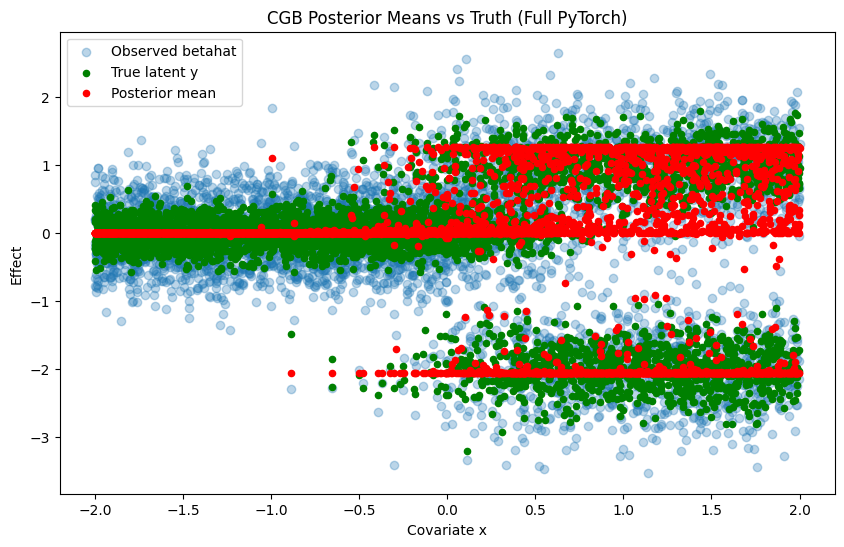

MSE(post_mean, y) = 0.1065
MSE(post_mean, y) = 0.1593


AttributeError: 'Cgb2PosteriorResult' object has no attribute 'mu_2'

In [33]:

y = torch.empty(N, device=device)
y[comp == 0] = torch.normal(mean=mu1_true, std=sig1_true, size=(int((comp == 0).sum()),), device=device) 
y[comp == 1] = torch.normal(mean=mu2_true, std=sig2_true, size=(int((comp == 1).sum()),), device=device) 

y[comp == 2] = torch.normal(mean=mu3_true, std=sig3_true, size=(int((comp == 2).sum()),), device=device) 
# observed betahat = y + obs noise
betahat    = y + torch.normal(mean=0.0, std=sd_noise, size=(N,), device=device)
sebetahat  = torch.full((N,), sd_noise, dtype=torch.float32, device=device)

# =======================
# Fit & evaluate
# =======================
res =sharp_2cgb_posterior_means(
    x, betahat, sebetahat, n_epochs=50, lr=1e-2, penalty=2.1
)

# Move to CPU for plotting / numpy ops
x_cpu         = x.detach().cpu()
betahat_cpu   = betahat.detach().cpu()
y_cpu         = y.detach().cpu()
post_mean_cpu = res.post_mean.detach().cpu()

# Plot
plt.figure(figsize=(10,6))
plt.scatter(x_cpu, betahat_cpu, alpha=0.3, label="Observed betahat")
plt.scatter(x_cpu, y_cpu, c="green", s=20, label="True latent y")
plt.scatter(x_cpu, post_mean_cpu, c="red", s=20, label="Posterior mean")
plt.xlabel("Covariate x"); plt.ylabel("Effect")
plt.title("CGB Posterior Means vs Truth (Full PyTorch)")
plt.legend(); plt.show()

mse = torch.mean((res.post_mean - y).pow(2)).item()
mse_noise = torch.mean((betahat - y).pow(2)).item()
print(f"MSE(post_mean, y) = {mse:.4f}")
print(f"MSE(post_mean, y) = {mse_noise:.4f}")
print(f"Learned μ2 ≈ {res.mu_2:.3f}  (true {mu2_true})")
print(f"Learned σ2 ≈ {res.sigma_2:.3f}  (true {sig2_true})")

In [ ]:

 
res.loss

4840.06494140625

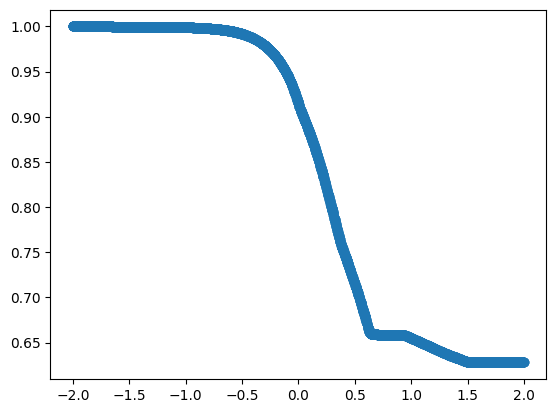

In [34]:
plt.scatter(x_cpu,res.pi)